# 04 — Sensitivity: PegCapture against `captureShare`

**This is not part of the pre-registered analysis plan.** It is reported as a
sensitivity analysis and must never be merged into `results/analysis.csv`, whose
FDR threshold was set over a family declared in advance.

It exists because `PegCapture` is the only policy with a positive headline
result, and that result rests on `captureShare = 0.5` — a constant chosen while
writing the hook, not declared beforehand. Reporting the number without sweeping
the parameter would invite exactly the objection it deserves.

**Needs:** `results/sensitivity/capture_share.csv`:

```bash
uv run python -m experiments.sensitivity     # 504 cells, ETH/SHIB, ~6 min
```


In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))

from experiments.figures import capture_share_sensitivity
from experiments.sensitivity import RESULTS, analyse

FIGURES = ROOT / "paper" / "Image"
FIGURES.mkdir(parents=True, exist_ok=True)

sweep = pd.read_csv(RESULTS / "capture_share.csv")
ok = sweep[sweep["error"].isna()]
worst = ok[["conservation_error_token0", "conservation_error_token1"]].abs().max().max()
print(f"{len(sweep)} cells, {sweep['error'].notna().sum()} errors")
print(f"worst conservation error: {worst:.2e}")

1512 cells, 0 errors
worst conservation error: 4.93e-16


In [2]:
ok.groupby("capture_share").agg(
    trades=("trade_count", "mean"),
    fees=("fee_income", "mean"),
    net=("net_result", "mean"),
    volume=("retained_volume", "mean"),
).round(1)

,trades,fees,net,volume
capture_share,,,,
100000,264.8,1181.2,-5985.1,2960660.2
250000,217.8,2525.4,-4678.5,2305456.2
500000,146.8,4039.7,-3275.3,1427886.4
750000,80.5,4745.8,-2699.8,738828.0
800000,66.9,4759.9,-2712.4,635730.7
850000,51.1,4715.9,-2786.8,541741.5
900000,36.4,4655.6,-2856.8,479878.0


The grid runs to 0.90 rather than stopping at 0.75 on purpose. Net result rises
monotonically up to 0.75, and a single probe at 0.90 traded zero times in one
window — so the turnover sits inside that gap, and a grid ending at 0.75 would
have reported its own boundary as an optimum.

The degeneracy at `captureShare → 1` therefore bites well before 1.0: the band
closes on the pool price and the arbitrageur, who must also clear gas, stops
trading.


## Against the static baseline, paired by window

Same machinery as the pre-registered analysis — Wilcoxon signed-rank, then
Benjamini–Hochberg at `q = 0.05` — but over its own family.


In [3]:
tests = analyse(sweep)
print(f"{int(tests['significant_fdr'].sum())}/{len(tests)} significant after BH")
tests.pivot_table(index="share", columns="regime", values="median").round(1)

24/28 significant after BH


regime,ALL,high,low,mid
share,,,,
0.10,-928.6,-3107.9,-435.5,-970.4
0.25,-489.1,-1412.7,-207.0,-467.1
0.50,46.1,540.4,-2.1,-0.5
0.75,224.1,1586.9,31.6,224.8
0.80,242.4,1745.5,-12.0,284.0
0.85,234.5,1649.5,-79.8,268.4
0.90,216.3,1558.1,-100.6,294.1


In [4]:
tests[tests["regime"] == "ALL"][
    ["share", "n", "median", "win_rate", "p", "significant_fdr"]
].round(4)

,share,n,median,win_rate,p,significant_fdr
3,0.10,216,-928.6053,0.0231,0.0000,True
7,0.25,216,-489.1339,0.1250,0.0000,True
11,0.50,216,46.0864,0.5741,0.0003,True
15,0.75,216,224.0594,0.7778,0.0000,True
19,0.80,216,242.3919,0.7176,0.0000,True
23,0.85,216,234.4664,0.6574,0.0000,True
27,0.90,216,216.2677,0.6296,0.0000,True


Three conclusions, and all three belong in the paper:

1. **0.5 is not the optimum, and not cherry-picked.** It is the _weakest_
   winning setting — the smallest positive median of those that win, and not
   significant in mid or low volatility. The pre-registered constant is
   conservative, which is the right direction for a value the author chose.
2. **The sign flips below 0.5.** At 0.1 `PegCapture` significantly _loses_ to
   static 30 bps in every regime. The policy is not robust to its own parameter,
   and the paper must say so rather than report a single tuned point.
3. **The optimum is interior**, and in low volatility nothing works: at 0.9 the
   policy significantly loses there.


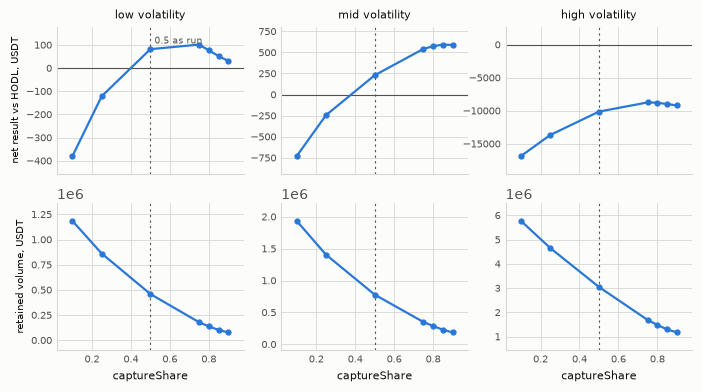

In [5]:
from IPython.display import Image, display

capture_share_sensitivity(sweep, FIGURES / "capture_share_sensitivity.pdf")
capture_share_sensitivity(sweep, FIGURES / "capture_share_sensitivity.png")
display(Image(filename=str(FIGURES / "capture_share_sensitivity.png")))

Each net-result panel keeps its own y scale: high volatility moves by thousands
and low by hundreds, so a shared scale flattens the low and mid curves onto zero
and hides the sign change, which is the entire point of the sweep.

The volume row is not decoration. The parameter works by leaving the
arbitrageur less, so "earns more" and "trades less" move together; net result
shown alone would reward the degenerate answer.
